In [4]:
from functools import partial

import jax
from jax import numpy as jnp
import numpy as np
import einops

import equinox as eqx
from equinox.nn import Linear

from typing import Optional
from jaxtyping import Float, Array, PRNGKeyArray

import matplotlib.pyplot as plt

from jepax.data import build_torch_dataloader as build_dataset
from jepax.model.transformer import PositionalEncoding2D
from jepax.model.masker import IJEPAMasker, patchify, unpatchify, visualize_mask

dataloader, _, _, _ = build_dataset("CIFAR10", data_dir="~/data")
x, y = next(iter(dataloader))

show_mask = lambda x, mask: visualize_mask(x, mask, 2, 16)

/Users/anton/source/jepax/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


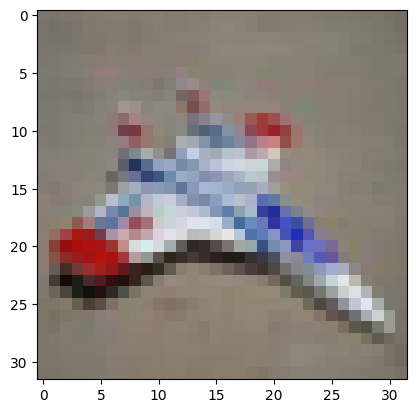

In [5]:
x_in = x[-2]
plt.imshow(x_in)

In [35]:
masker = IJEPAMasker(32, 32, 2, ctx_scale=0.8, ctx_aspect=1.0, pred_scale=0.2, pred_aspect=(0.9, 1.2))
M = 4

@partial(jax.jit, static_argnums=(1,2))
def create_mask(key, M, flatten):
    return masker(key, M, flatten=flatten)

key = jax.random.PRNGKey(11)
mask_ctx, mask_pred = create_mask(key, M, flatten=False)

print(mask_ctx.shape, mask_pred.shape)

(16, 16) (4, 16, 16)


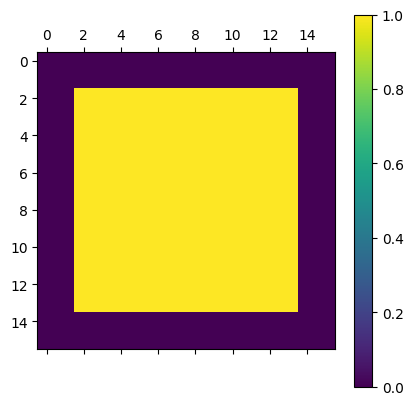

In [36]:
plt.matshow(mask_ctx)
plt.colorbar()

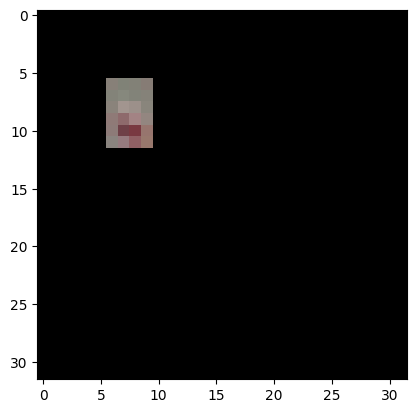

In [39]:
plt.imshow(show_mask(x_in, mask_pred[3].flatten()))

In [40]:
mask_pred.flatten()

Array([False, False, False, ..., False, False, False], dtype=bool)

## Mask Padding

In [41]:
x_in = x[-2]
x_tok = patchify(x_in, 2)

posenc2d = PositionalEncoding2D(16, 12)

/var/folders/82/kqk386yx56s3vbqsdcrdr_wc0000gn/T/ipykernel_25992/2767986638.py:4: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  posenc2d = PositionalEncoding2D(16, 12)


In [ ]:

def get_pred_idx(mask_pred, n_pad=64, fill_value=-1):
    # flattens the mask
    mask_pred_flat = mask_pred.reshape(*mask_pred.shape[:1], -1)

    mask_idx = jnp.stack(jnp.where(mask_pred_flat, size=n_pad, fill_value=fill_value)[1:])[0]
    mask_idx_pos = jnp.stack(jnp.where(mask_pred, size=n_pad, fill_value=fill_value)[1:])

    return mask_idx, mask_idx_pos

mask_idx, mask_idx_pos = get_pred_idx(mask_pred)

In [73]:
mask_idx.shape

(64,)

In [74]:
mask_idx

Array([ 0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,
        2,  3,  3,  3,  3,  3,  3, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1], dtype=int32)

In [71]:
mask_idx_pos

Array([[11, 11, 12, 12, 13, 13,  8,  8,  9,  9, 10, 10,  6,  6,  7,  7,
         8,  8,  3,  3,  4,  4,  5,  5, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
       [ 0,  1,  0,  1,  0,  1,  2,  3,  2,  3,  2,  3,  9, 10,  9, 10,
         9, 10,  3,  4,  3,  4,  3,  4, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1]],      dtype=int32)

In [44]:
256 + 64

320

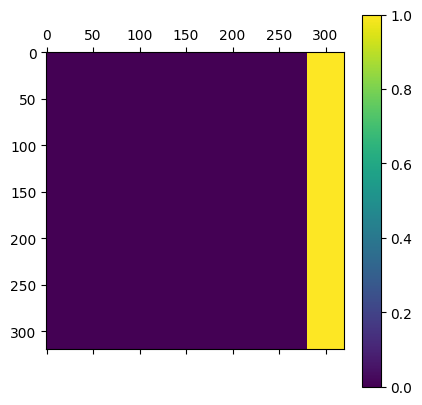

In [75]:
@partial(jax.jit, static_argnames=('n_pad', 'n_prev'))
def get_pred_attn_mask(mask_idx, n_pad, n_prev=0):
    # mask out junk
    attn_mask = jnp.concatenate([jnp.zeros(n_prev), mask_idx < 0])
    return jnp.repeat(attn_mask[None, :], n_prev + n_pad, axis=0).astype(bool)

# first number of tokens should be padded
attn_mask = get_pred_attn_mask(mask_idx, n_pad=64, n_prev=256)

causal = jnp.tri(320, 320).T.astype(bool)

plt.matshow(get_pred_attn_mask(mask_idx, n_pad=64, n_prev=256))
plt.colorbar()

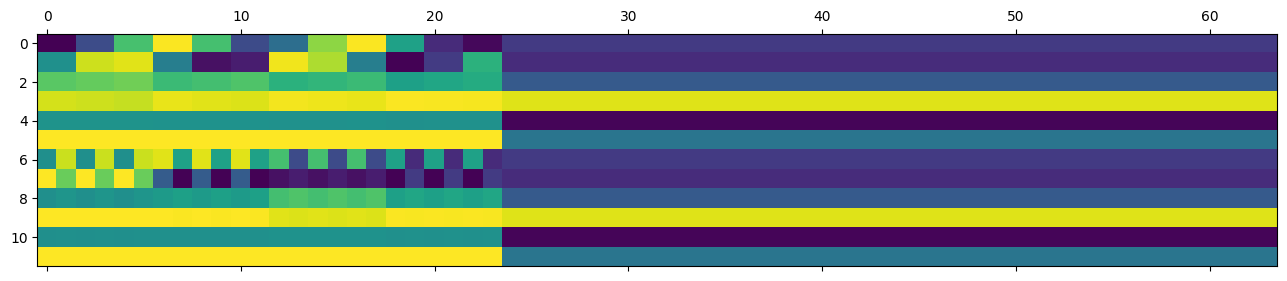

In [46]:
mask_pos_enc = posenc2d._get_pe_from_grid(mask_idx_pos)
plt.matshow(mask_pos_enc.T)

In [47]:
x_tok.shape

(256, 12)

In [48]:
mask_idx[mask_idx >= 0]

Array([176, 177, 192, 193, 208, 209, 130, 131, 146, 147, 162, 163, 105,
       106, 121, 122, 137, 138,  51,  52,  67,  68,  83,  84],      dtype=int32)

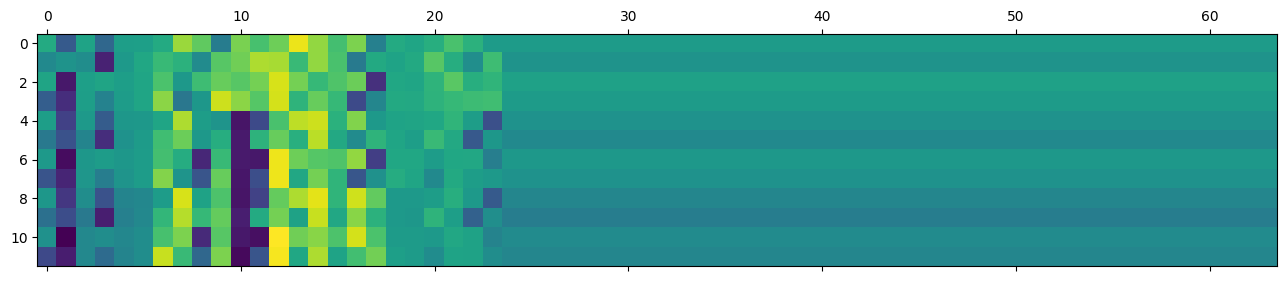

In [49]:
x_tok[mask_idx].shape
plt.matshow(x_tok[mask_idx].T)

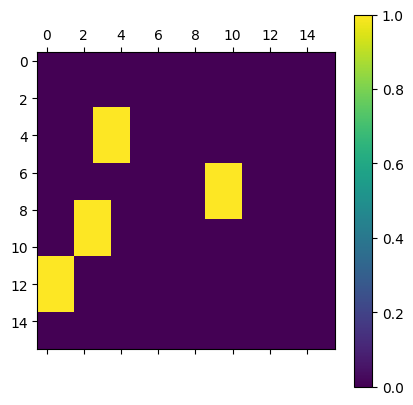

In [50]:
plt.matshow(mask_pred.any(axis=0))
plt.colorbar()

In [82]:
mask_idx = jnp.where((mask_pred.any(axis=0).flatten() > 0), size=64, fill_value=-1)[0]
mask_idx

Array([ 51,  52,  67,  68,  83,  84, 105, 106, 121, 122, 130, 131, 137,
       138, 146, 147, 162, 163, 176, 177, 192, 193, 208, 209,  -1,  -1,
        -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
        -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,
        -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1,  -1],      dtype=int32)

## Predictor

In [ ]:
from jepax.model.masker import set_token_mask
from jepax.model.transformer import Transformer, PositionalEncoding
from jepax.model.vit import PatchEmbedding
    
class IJEPAPredictor(eqx.Module):
    in_proj: eqx.nn.Linear
    out_proj: eqx.nn.Linear
    transformer: Transformer

    pred_token: Array
    mask_token: Array

    pe: PositionalEncoding2D

    def __init__(
        self,
        latent_dim: int,
        dim: int,
        grid_size: int,
        num_layers: int,
        num_head: int,
        mlp_ratio: float = 3.0,
        p_drop: float = 0.1,
        seq_len: int = 2048,
        *,
        key: PRNGKeyArray
    ):
        k1, k2, k3, k4, k5 = jax.random.split(key, 5)

        self.in_proj = eqx.nn.Linear(dim, latent_dim, key=k1)
        self.transformer = Transformer(
            dim=latent_dim, 
            num_layers=num_layers,
            num_head=num_head,
            mlp_ratio=mlp_ratio,
            p_drop=p_drop,
            seq_len=seq_len,
            key=k2
        )
        self.mask_token = jax.random.normal(k3, (1, latent_dim))
        self.pred_token = jax.random.normal(k4, (1, latent_dim))
        self.out_proj = eqx.nn.Linear(latent_dim, dim, key=k5)
        self.pe = PositionalEncoding2D(dim=latent_dim, seq_len=seq_len, grid_size=grid_size)

    #@partial(jax.jit, static_argnames=('num_pad', 'num_prev'))
    def _get_pred_attn_mask(self, mask_idx, mask_ctx, num_prev=0):
        # NOTE: mask is 0 for tokens we attend
        attn_mask = jnp.concatenate([jnp.zeros(num_prev), mask_idx < 0])
        return jnp.repeat(attn_mask[None, :], num_prev + len(mask_idx), axis=0).astype(bool)

    def __call__(self, key, 
                 x: Float[Array, "T D"], 
                 mask_pred: Float[Array, "Bm G G"], 
                 mask_ctx: Float[Array, "G G"]
                 train=True):
        x = jax.vmap(self.in_proj)(x) # vmap proj over token

        # put mask token at tokens outside context
        x = jnp.where(~mask_ctx[:, None], self.mask_token, x)

        # put pred token at positions in mask_pred
        mask_target = mask_pred.any(axis=0)
        x = jnp.where(mask_target[:, None].flatten(), self.pred_token, x)

        x = self.transformer(x, key=key, train=train, use_pe=True)

        x = jax.vmap(self.out_proj)(x)

        return x, mask_target

In [99]:
key = jax.random.PRNGKey(0)
model = IJEPAPredictor(
    key=key,
    latent_dim=32,
    grid_size=16,
    dim=12,
    num_head=2,
    num_layers=1
)
x = jax.random.normal(key, (256, 12))

x_pred, mask_full = model(key, x, mask_pred, num_pad=64)
print(x_pred.shape)

/var/folders/82/kqk386yx56s3vbqsdcrdr_wc0000gn/T/ipykernel_25992/2731775128.py:43: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  self.pe = PositionalEncoding2D(dim=latent_dim, seq_len=seq_len, grid_size=grid_size)


ValueError: Incompatible shapes for broadcasting: shapes=[(256,), (1, 32), (256, 32)]

In [91]:
jit_model = eqx.filter_jit(model)
jit_model(key, x, mask_pred, num_pad=64)

Array([[-0.8170783 , -0.06268544,  0.04128626, ..., -0.05410266,
         0.2665629 ,  0.78611976],
       [ 0.5403732 ,  0.78556466, -0.06412135, ..., -1.0329982 ,
         0.4927737 , -0.6256374 ],
       [ 0.368427  ,  0.28787675,  0.08642791, ..., -1.4032917 ,
        -0.19606486, -0.23327902],
       ...,
       [-0.4079151 ,  0.83308864,  0.07559913, ..., -1.0910585 ,
        -0.5377145 ,  0.72808087],
       [-0.20985447,  0.7984796 , -0.09831938, ..., -0.01581913,
        -0.34158453,  0.23832959],
       [ 0.48866087, -0.29218084, -0.22299294, ...,  1.0471286 ,
        -0.4681255 ,  0.28180513]], dtype=float32)

In [92]:
mask_pred.shape

(4, 16, 16)

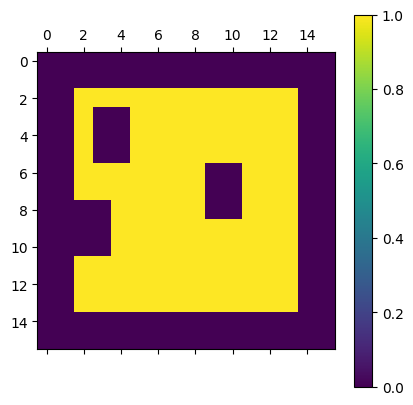

In [94]:
mask_enc = ~(~mask_ctx | jnp.any(mask_pred, axis=0))
plt.matshow(mask_enc)
plt.colorbar()

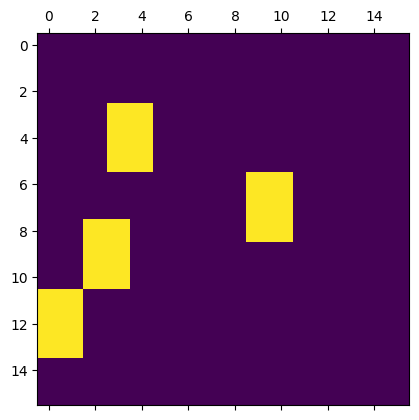

In [101]:
mask_enc = ~(~mask_ctx | jnp.any(mask_pred, axis=0))

plt.matshow(jnp.any(mask_pred, axis=0))


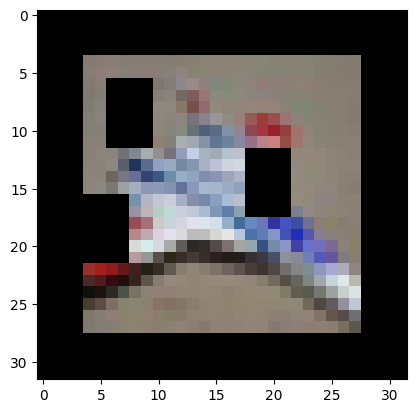

In [95]:
plt.imshow(show_mask(x_in, mask_enc.flatten()))

- create forward pass by concatenating prev tokens + pred mask
- add the mask, variable mask sizes for bucketing
- specify fill value: -1, add fill token
- 